# 02_Predictive_Modeling.ipynb

Sustainable Energy Production & Demand Forecasting

**Purpose:** Build reproducible demand & production forecasting pipelines, evaluate models with time-series cross-validation, and save results for reporting.



#### 1. Setup & imports

In [16]:
# %% [code]
# --- 1. Setup & imports ---
import os
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from datetime import timedelta

pd.set_option("display.max_columns", 200)
plt.style.use("seaborn-v0_8-whitegrid")

# Paths - adjust if needed
BASE_DIR = Path(".")
DATA_DIR = (BASE_DIR / ".." / "synthetic_energy_csvs").resolve()
REPORTS_DIR = (BASE_DIR / ".." / "reports").resolve()
MODELS_DIR = (BASE_DIR / ".." / "models").resolve()
for d in [REPORTS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("REPORTS_DIR:", REPORTS_DIR)
print("MODELS_DIR:", MODELS_DIR)


DATA_DIR: D:\synthetic_energy_csvs
REPORTS_DIR: D:\reports
MODELS_DIR: D:\models


#### 2. Load data

In [17]:
# %% [code]
# --- 2. Load data ---
plants = pd.read_csv(DATA_DIR / "Plants.csv")
prod = pd.read_csv(DATA_DIR / "EnergyProduction.csv", parse_dates=["RecordDate"])
cons = pd.read_csv(DATA_DIR / "Consumption.csv", parse_dates=["RecordDate"])
weather = pd.read_csv(DATA_DIR / "WeatherSnapshots.csv", parse_dates=["SnapshotDate"])
forecast = pd.read_csv(DATA_DIR / "ForecastSnapshots.csv", parse_dates=["ForecastDate"])

print("Shapes:")
print("Plants", plants.shape)
print("Production", prod.shape)
print("Consumption", cons.shape)
print("Weather", weather.shape)
print("Forecast", forecast.shape)

# Quick glance
plants.head()


Shapes:
Plants (30, 7)
Production (76710, 8)
Consumption (61368, 6)
Weather (15342, 7)
Forecast (15342, 6)


,PlantID,PlantName,Region,EnergyType,InstalledCapacityMW,CommissionDate,Status
0,1,Plant_001,Coastal,Solar,115.49,2022-02-27,Operational
1,2,Plant_002,South,Solar,285.46,2018-07-29,Operational
2,3,Plant_003,Central,Solar,220.94,2020-05-14,Operational
3,4,Plant_004,North,Solar,181.60,2020-10-31,Operational
4,5,Plant_005,Central,Solar,51.03,2021-08-23,Operational


#### 3. Aggregate to region-day level (demand forecasting dataset)

In [18]:
# %% [code]
# --- 3. Aggregate to region-day level (demand forecasting dataset) ---

# 1️⃣ Aggregate consumption -> region-day demand
cons_region = (
    cons.groupby(["Region", "RecordDate"], as_index=False)["EnergyConsumedMWh"]
    .sum()
    .rename(columns={"EnergyConsumedMWh": "ActualDemandMWh"})
)

# 2️⃣ Merge production with plant regions
prod_with_region = prod.merge(plants[["PlantID", "Region"]], on="PlantID", how="left")

# Fix any duplicate region columns
if "Region_y" in prod_with_region.columns:
    prod_with_region["Region"] = prod_with_region["Region_y"]
elif "Region_x" in prod_with_region.columns:
    prod_with_region["Region"] = prod_with_region["Region_x"]

prod_with_region.drop(columns=["Region_x", "Region_y"], errors="ignore", inplace=True)

# 3️⃣ Aggregate production -> region-day
prod_region = (
    prod_with_region.groupby(["Region", "RecordDate"], as_index=False)["EnergyGeneratedMWh"]
    .sum()
    .rename(columns={"EnergyGeneratedMWh": "ActualProductionMWh"})
)

# 4️⃣ Merge region-level datasets
region_df = cons_region.merge(prod_region, on=["Region", "RecordDate"], how="left")

# Weather data
weather_ren = weather.rename(columns={"SnapshotDate": "RecordDate"})
region_df = region_df.merge(
    weather_ren[
        ["Region", "RecordDate", "AvgTemperature", "SolarRadiation", "WindSpeed", "RainfallMM"]
    ],
    on=["Region", "RecordDate"],
    how="left",
)

# Forecast data
forecast_ren = forecast.rename(
    columns={
        "ForecastDate": "RecordDate",
        "PredictedDemandMWh": "ForecastDemandMWh",
        "PredictedProductionMWh": "ForecastProductionMWh",
    }
)
region_df = region_df.merge(
    forecast_ren[
        ["Region", "RecordDate", "ForecastDemandMWh", "ForecastProductionMWh"]
    ],
    on=["Region", "RecordDate"],
    how="left",
)

# 5️⃣ Build continuous daily frequency per region
region_df = region_df.sort_values(["Region", "RecordDate"]).reset_index(drop=True)
region_df["RecordDate"] = pd.to_datetime(region_df["RecordDate"])

# Correct way: use groupby().agg() to compute min/max per region
region_date_ranges = (
    region_df.groupby("Region")["RecordDate"]
    .agg(min_date="min", max_date="max")
    .reset_index()
)

# Generate full continuous date ranges
complete_dates = []
for _, row in region_date_ranges.iterrows():
    dates = pd.date_range(start=row["min_date"], end=row["max_date"], freq="D")
    temp = pd.DataFrame({"Region": row["Region"], "RecordDate": dates})
    complete_dates.append(temp)
complete_dates = pd.concat(complete_dates, ignore_index=True)

# Merge back to get a full continuous region-day matrix
region_df = complete_dates.merge(region_df, on=["Region", "RecordDate"], how="left")

# 6️⃣ Forward/backward fill missing data
fill_cols = [
    "ActualDemandMWh",
    "ActualProductionMWh",
    "AvgTemperature",
    "SolarRadiation",
    "WindSpeed",
    "RainfallMM",
    "ForecastDemandMWh",
    "ForecastProductionMWh",
]

region_df[fill_cols] = (
    region_df.groupby("Region")[fill_cols]
    .transform(lambda g: g.ffill().bfill())
)

# 7️⃣ Drop rows missing essential target values
region_df = region_df.dropna(subset=["ActualDemandMWh"]).reset_index(drop=True)

# ✅ Final sanity check
print("✅ Region-level data shape:", region_df.shape)
display(region_df.head())


✅ Region-level data shape: (15342, 10)


,Region,RecordDate,ActualDemandMWh,ActualProductionMWh,AvgTemperature,SolarRadiation,WindSpeed,RainfallMM,ForecastDemandMWh,ForecastProductionMWh
0,Central,2018-01-01,5196.637,2196.607,22.33,529.33,8.45,1.07,4881.163879,2244.201829
1,Central,2018-01-02,6452.977,1767.701,20.98,460.49,5.87,0.01,6668.260796,1785.283108
2,Central,2018-01-03,6538.142,2477.291,26.17,589.45,9.64,0.16,5567.228044,2504.402337
3,Central,2018-01-04,5573.993,1792.761,22.91,452.39,8.16,0.19,5715.219075,1806.902134
4,Central,2018-01-05,6303.514,2558.765,24.75,557.02,9.33,0.30,6606.728846,2575.670794


#### 4. Feature engineering

In [19]:
# %% [code]
# --- 4. Feature engineering ---
df = region_df.copy()

# Time features
df['Year'] = df['RecordDate'].dt.year
df['Month'] = df['RecordDate'].dt.month
df['Day'] = df['RecordDate'].dt.day
df['DayOfWeek'] = df['RecordDate'].dt.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['DayOfYear'] = df['RecordDate'].dt.dayofyear
df['WeekOfYear'] = df['RecordDate'].dt.isocalendar().week

# Lag features for demand (1,2,3,7,14,30 days)
lags = [1,2,3,7,14,30]
for lag in lags:
    df[f'lag_demand_{lag}'] = df.groupby('Region')['ActualDemandMWh'].shift(lag)

# Rolling means
df['r7_demand'] = df.groupby('Region')['ActualDemandMWh'].transform(lambda s: s.rolling(7, min_periods=1).mean())
df['r30_demand'] = df.groupby('Region')['ActualDemandMWh'].transform(lambda s: s.rolling(30, min_periods=1).mean())

# Weather features: already present; normalise later
df['SolarRadiation'] = df['SolarRadiation'].astype(float)
df['WindSpeed'] = df['WindSpeed'].astype(float)
df['Temp_delta_7'] = df.groupby('Region')['AvgTemperature'].transform(lambda s: s - s.rolling(7, min_periods=1).mean())

# Target
df['TargetDemand'] = df['ActualDemandMWh']

# Remove initial rows with too many NaNs from lagging
df = df.groupby('Region').apply(lambda g: g.iloc[ max(lags)+1 : ]).reset_index(drop=True)

print("After FE shape:", df.shape)
df.head()


After FE shape: (15156, 27)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12868\2419567082.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Region').apply(lambda g: g.iloc[ max(lags)+1 : ]).reset_index(drop=True)


,Region,RecordDate,ActualDemandMWh,ActualProductionMWh,AvgTemperature,SolarRadiation,WindSpeed,RainfallMM,ForecastDemandMWh,ForecastProductionMWh,Year,Month,Day,DayOfWeek,IsWeekend,DayOfYear,WeekOfYear,lag_demand_1,lag_demand_2,lag_demand_3,lag_demand_7,lag_demand_14,lag_demand_30,r7_demand,r30_demand,Temp_delta_7,TargetDemand
0,Central,2018-02-01,6317.552,3100.238,24.81,671.05,9.11,0.20,6032.291220,3096.713992,2018,2,1,3,0,32,5,8133.411,6493.313,6780.989,6601.522,6082.201,6452.977,6759.755857,6459.514500,-2.335714,6317.552
1,Central,2018-02-02,7081.260,2846.143,27.66,676.58,7.54,0.12,7329.639288,2995.537574,2018,2,2,4,0,33,5,6317.552,8133.411,6493.313,7020.007,6803.643,6538.142,6768.506286,6477.618433,0.492857,7081.260
2,Central,2018-02-03,6417.785,2603.452,27.62,673.97,8.39,0.00,6771.485148,2591.910137,2018,2,3,5,1,34,5,7081.260,6317.552,8133.411,6109.145,6312.115,5573.993,6812.597714,6505.744833,-0.025714,6417.785
3,Central,2018-02-04,7416.025,2694.326,28.62,686.28,7.16,0.38,7614.507978,2999.223412,2018,2,4,6,1,35,5,6417.785,7081.260,6317.552,6463.874,6414.841,6303.514,6948.619286,6542.828533,0.580000,7416.025
4,Central,2018-02-05,7224.681,2879.885,26.33,619.43,6.45,0.12,7374.357085,2960.871305,2018,2,5,0,0,36,6,7416.025,6417.785,7081.260,6780.989,6270.877,6133.059,7012.003857,6579.215933,-1.312857,7224.681


#### 5. Modeling helper functions (train per-region with time-aware split)

In [20]:
# --- 5. Helper Functions (clean + safe) ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import joblib, json
from pathlib import Path

def prepare_X_y(df):
    """
    Prepare features (X) and target (y) for modeling.
    Drops columns not relevant for prediction, handles missing values, and encodes categorical vars.
    """
    df = df.copy()
    y = df['TargetDemand']
    X = df.drop(columns=['TargetDemand', 'RecordDate'], errors='ignore')
    
    # encode categorical
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    
    # fill missing values safely
    X = X.ffill().bfill().fillna(0)
    
    return X, y, X.columns.tolist()


def time_split(X, y, test_days=365):
    """
    Simple chronological split assuming daily granularity.
    """
    split_idx = int(len(X) - test_days)
    if split_idx < 0:
        split_idx = int(0.8 * len(X))  # fallback
    return X.iloc[:split_idx], X.iloc[split_idx:], y.iloc[:split_idx], y.iloc[split_idx:]


def evaluate_preds(y_true, y_pred):
    """
    Compute common regression metrics with backward compatibility for old sklearn versions.
    """
    try:
        rmse = mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'MAE': float(mae), 'RMSE': float(rmse), 'R2': float(r2)}

#### 6. Train models per region, collect metrics, and save top models

In [21]:
# --- 6. Train models per region, collect metrics, and save top models ---
DATA_DIR = Path("../synthetic_energy_csvs")
REPORTS_DIR = Path("../reports")
MODELS_DIR = Path("../models")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

regions = df['Region'].unique().tolist()
results = {}
saved_models = {}

print("Columns in df:", df.columns.tolist())
print("Sample rows:")
display(df.head())

for region in regions:
    print(f"\nTraining region: {region}")
    region_df_local = df[df.Region == region].sort_values('RecordDate').reset_index(drop=True).copy()
    X, y, feats = prepare_X_y(region_df_local)
    
    # Test split
    X_train, X_test, y_train, y_test = time_split(X, y, test_days=365)
    if len(X_train) < 30:
        print(f"  Skipping {region}: not enough training data ({len(X_train)} rows).")
        continue

    # Scale numeric features
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

    # Define models
    models = {
        'Linear': LinearRegression(),
        'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=200, random_state=42)
    }

    region_results = {}
    region_models = {}
    for name, model in models.items():
        try:
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
            metrics = evaluate_preds(y_test, preds)
            region_results[name] = metrics
            region_models[name] = {'model': model, 'scaler': scaler, 'features': feats}
            print(f"  {name}: MAE={metrics['MAE']:.2f}, RMSE={metrics['RMSE']:.2f}, R2={metrics['R2']:.3f}")
        except Exception as e:
            print(f"  Failed {name} for {region}: {e}")

    if not region_results:
        print(f"  ⚠️ No successful model for {region}. Skipping save.")
        continue

    # Choose best by RMSE
    best_model_name = min(region_results.keys(), key=lambda k: region_results[k]['RMSE'])
    best = region_models[best_model_name]
    saved_path = MODELS_DIR / f"forecast_{region}_{best_model_name}.joblib"
    joblib.dump({'model': best['model'], 'scaler': best['scaler'], 'features': best['features']}, saved_path)
    print(f"  ✅ Saved best model ({best_model_name}) to {saved_path.name}")

    results[region] = region_results
    saved_models[region] = {'best': best_model_name, 'path': str(saved_path)}

# Save metrics summary
with open(REPORTS_DIR / "demand_model_metrics.json", "w") as f:
    json.dump(results, f, indent=2)

rows = []
for reg, mets in results.items():
    for model_name, m in mets.items():
        rows.append({'Region': reg, 'Model': model_name, **m})
pd.DataFrame(rows).to_csv(REPORTS_DIR / "demand_model_metrics.csv", index=False)
print("\n✅ Saved model metrics and artifacts.")

Columns in df: ['Region', 'RecordDate', 'ActualDemandMWh', 'ActualProductionMWh', 'AvgTemperature', 'SolarRadiation', 'WindSpeed', 'RainfallMM', 'ForecastDemandMWh', 'ForecastProductionMWh', 'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend', 'DayOfYear', 'WeekOfYear', 'lag_demand_1', 'lag_demand_2', 'lag_demand_3', 'lag_demand_7', 'lag_demand_14', 'lag_demand_30', 'r7_demand', 'r30_demand', 'Temp_delta_7', 'TargetDemand']
Sample rows:


,Region,RecordDate,ActualDemandMWh,ActualProductionMWh,AvgTemperature,SolarRadiation,WindSpeed,RainfallMM,ForecastDemandMWh,ForecastProductionMWh,Year,Month,Day,DayOfWeek,IsWeekend,DayOfYear,WeekOfYear,lag_demand_1,lag_demand_2,lag_demand_3,lag_demand_7,lag_demand_14,lag_demand_30,r7_demand,r30_demand,Temp_delta_7,TargetDemand
0,Central,2018-02-01,6317.552,3100.238,24.81,671.05,9.11,0.20,6032.291220,3096.713992,2018,2,1,3,0,32,5,8133.411,6493.313,6780.989,6601.522,6082.201,6452.977,6759.755857,6459.514500,-2.335714,6317.552
1,Central,2018-02-02,7081.260,2846.143,27.66,676.58,7.54,0.12,7329.639288,2995.537574,2018,2,2,4,0,33,5,6317.552,8133.411,6493.313,7020.007,6803.643,6538.142,6768.506286,6477.618433,0.492857,7081.260
2,Central,2018-02-03,6417.785,2603.452,27.62,673.97,8.39,0.00,6771.485148,2591.910137,2018,2,3,5,1,34,5,7081.260,6317.552,8133.411,6109.145,6312.115,5573.993,6812.597714,6505.744833,-0.025714,6417.785
3,Central,2018-02-04,7416.025,2694.326,28.62,686.28,7.16,0.38,7614.507978,2999.223412,2018,2,4,6,1,35,5,6417.785,7081.260,6317.552,6463.874,6414.841,6303.514,6948.619286,6542.828533,0.580000,7416.025
4,Central,2018-02-05,7224.681,2879.885,26.33,619.43,6.45,0.12,7374.357085,2960.871305,2018,2,5,0,0,36,6,7416.025,6417.785,7081.260,6780.989,6270.877,6133.059,7012.003857,6579.215933,-1.312857,7224.681



Training region: Central
  Linear: MAE=0.00, RMSE=0.00, R2=1.000
  RandomForest: MAE=1.96, RMSE=5.60, R2=1.000
  GradientBoosting: MAE=6.43, RMSE=9.03, R2=1.000
  ✅ Saved best model (Linear) to forecast_Central_Linear.joblib

Training region: Coastal
  Linear: MAE=0.00, RMSE=0.00, R2=1.000
  RandomForest: MAE=2.26, RMSE=14.34, R2=1.000
  GradientBoosting: MAE=5.74, RMSE=10.05, R2=1.000
  ✅ Saved best model (Linear) to forecast_Coastal_Linear.joblib

Training region: East
  Linear: MAE=0.00, RMSE=0.00, R2=1.000
  RandomForest: MAE=4.41, RMSE=28.17, R2=1.000
  GradientBoosting: MAE=10.15, RMSE=21.19, R2=1.000
  ✅ Saved best model (Linear) to forecast_East_Linear.joblib

Training region: North
  Linear: MAE=0.00, RMSE=0.00, R2=1.000
  RandomForest: MAE=1.31, RMSE=2.91, R2=1.000
  GradientBoosting: MAE=5.57, RMSE=7.63, R2=1.000
  ✅ Saved best model (Linear) to forecast_North_Linear.joblib

Training region: South
  Linear: MAE=0.00, RMSE=0.00, R2=1.000
  RandomForest: MAE=3.26, RMSE=19.26,

#### 7. Scenario Forecast Simulation & Stress Testing

#### Using saved regional models, simulate demand forecasts under different scenarios:
#### - **Base case:** actual recent average weather
#### - **Heatwave:** +3°C average temperature
#### - **Low Wind:** -20% average wind speed
#### - **Renewable Boost:** +10% solar radiation

#### Results are visualized to assess system resilience and efficiency planning.


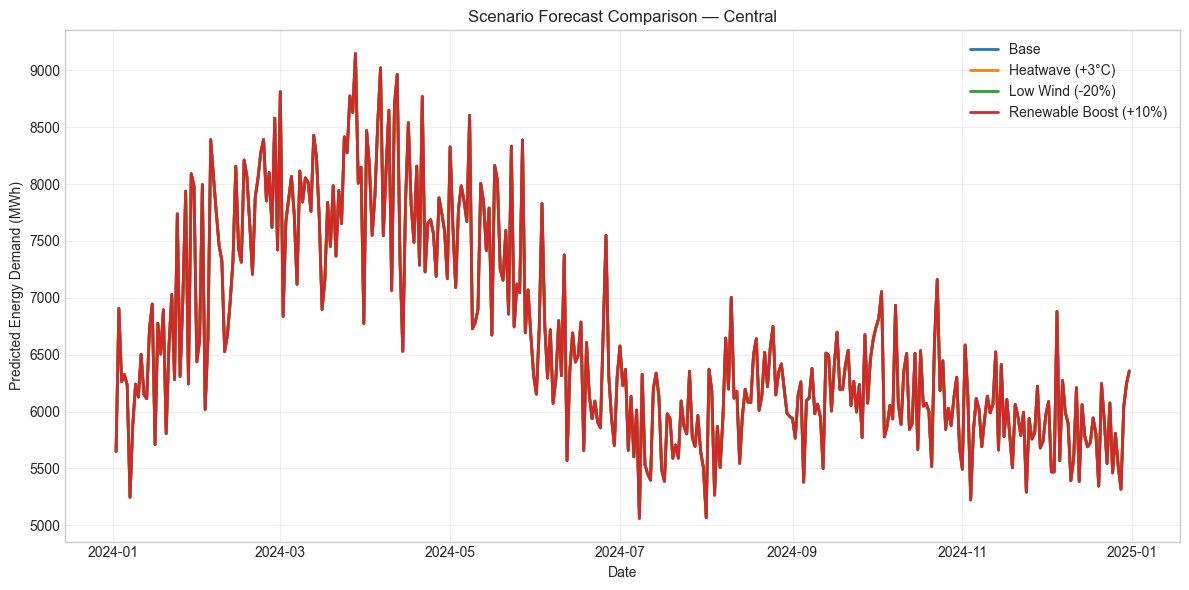

In [22]:
# %% [code]
# --- 7. Scenario Forecast Simulation & Stress Testing ---
import joblib
import numpy as np
import matplotlib.pyplot as plt

# Select region for simulation
region = "Central"   # You can change to any available region
model_info = saved_models.get(region, None)
if model_info is None:
    raise ValueError(f"No model found for region {region}")

# Load best model + scaler
model_artifact = joblib.load(model_info['path'])
model = model_artifact['model']
scaler = model_artifact['scaler']
features = model_artifact['features']

# Prepare recent data window for simulation
region_df = df[df.Region == region].sort_values("RecordDate").tail(365).copy()
X_recent = region_df[features].copy()

# Scale numeric columns
num_cols = X_recent.select_dtypes(include=[np.number]).columns.tolist()
X_recent_scaled = X_recent.copy()
X_recent_scaled[num_cols] = scaler.transform(X_recent[num_cols])

# Scenario adjustments
scenarios = {
    "Base": X_recent_scaled.copy(),
    "Heatwave (+3°C)": X_recent_scaled.assign(AvgTemperature=X_recent_scaled["AvgTemperature"] + 3),
    "Low Wind (-20%)": X_recent_scaled.assign(WindSpeed=X_recent_scaled["WindSpeed"] * 0.8),
    "Renewable Boost (+10%)": X_recent_scaled.assign(SolarRadiation=X_recent_scaled["SolarRadiation"] * 1.1)
}

# Predict for each scenario
sim_results = {}
for scen, data in scenarios.items():
    sim_results[scen] = model.predict(data)

# Plot the results
plt.figure(figsize=(12,6))
plt.plot(region_df['RecordDate'], sim_results['Base'], label='Base', lw=2)
plt.plot(region_df['RecordDate'], sim_results['Heatwave (+3°C)'], label='Heatwave (+3°C)', lw=2)
plt.plot(region_df['RecordDate'], sim_results['Low Wind (-20%)'], label='Low Wind (-20%)', lw=2)
plt.plot(region_df['RecordDate'], sim_results['Renewable Boost (+10%)'], label='Renewable Boost (+10%)', lw=2)
plt.title(f"Scenario Forecast Comparison — {region}")
plt.xlabel("Date")
plt.ylabel("Predicted Energy Demand (MWh)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### 8. Diagnostics & plots for a chosen region (example)
#### - Visualize actual vs predicted demand, residuals, and error distributions to evaluate the chosen model’s performance for a given region.

Diagnostics for region: Central


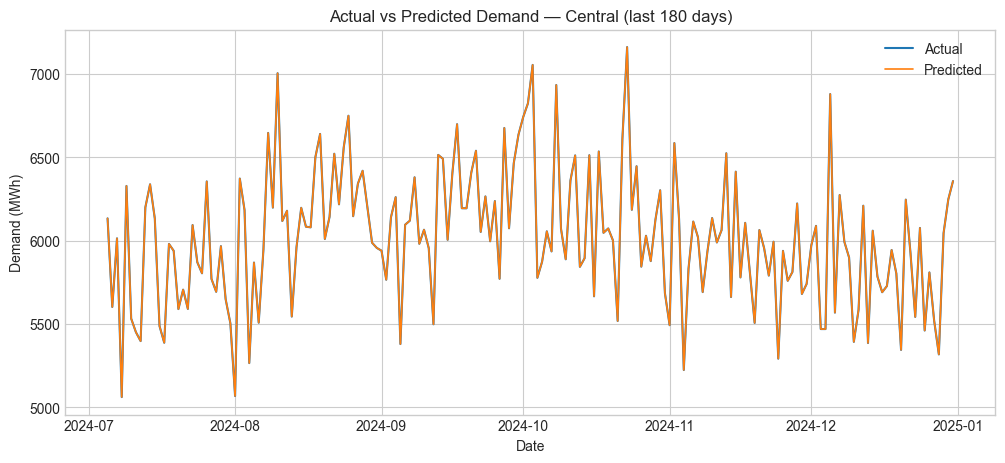

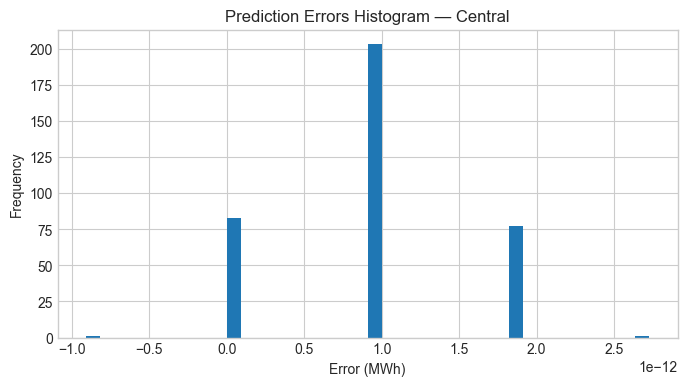

Model does not expose feature_importances_.


In [23]:
# %% [code]
# --- 8. Diagnostics & plots for a chosen region (example) ---
# Choose a region with a saved model
example_region = None
for r in saved_models:
    example_region = r
    break

if example_region is None:
    print("No region models saved - nothing to plot.")
else:
    print("Diagnostics for region:", example_region)
    # load saved model
    model_file = MODELS_DIR / Path(saved_models[example_region]['path']).name
    artifact = joblib.load(model_file)
    model = artifact['model']; scaler = artifact['scaler']; feats = artifact['features']

    # Prepare test set again
    rdf = df[df.Region==example_region].sort_values('RecordDate').reset_index(drop=True)
    X_all, y_all, _ = prepare_X_y(rdf)
    X_train, X_test, y_train, y_test = time_split(X_all, y_all, test_days=365)

    # scale test
    num_cols = X_test.select_dtypes(include=[np.number]).columns.tolist()
    X_test_scaled = X_test.copy()
    X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

    preds = model.predict(X_test_scaled)

    # Plot actual vs predicted (last 180 days for readability)
    display_len = min(180, len(y_test))
    plt.figure(figsize=(12,5))
    dates = rdf['RecordDate'].iloc[-len(y_test):]
    plt.plot(dates[-display_len:], y_test.values[-display_len:], label='Actual', linewidth=1.5)
    plt.plot(dates[-display_len:], preds[-display_len:], label='Predicted', linewidth=1.2)
    plt.title(f"Actual vs Predicted Demand — {example_region} (last {display_len} days)")
    plt.xlabel("Date"); plt.ylabel("Demand (MWh)")
    plt.legend(); plt.show()

    # Error histogram
    errors = preds - y_test.values
    plt.figure(figsize=(8,4))
    plt.hist(errors, bins=40)
    plt.title(f"Prediction Errors Histogram — {example_region}")
    plt.xlabel("Error (MWh)"); plt.ylabel("Frequency")
    plt.show()

    # Feature importance if model supports it
    try:
        importances = model.feature_importances_
        fi = pd.Series(importances, index=feats).sort_values(ascending=True).tail(20)
        plt.figure(figsize=(8,6))
        fi.plot(kind='barh')
        plt.title("Top feature importances (sample region)")
        plt.xlabel("Importance")
        plt.show()
    except Exception:
        print("Model does not expose feature_importances_.")


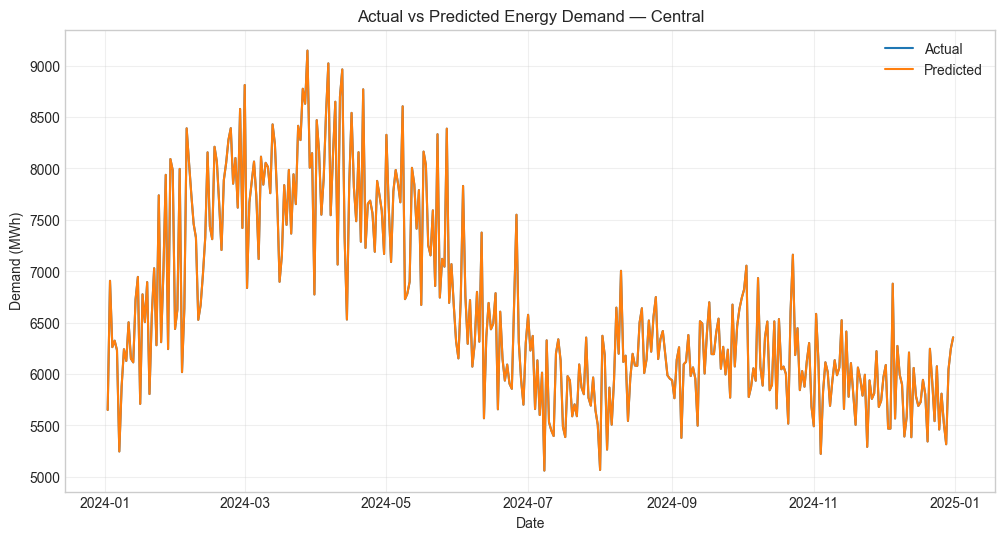

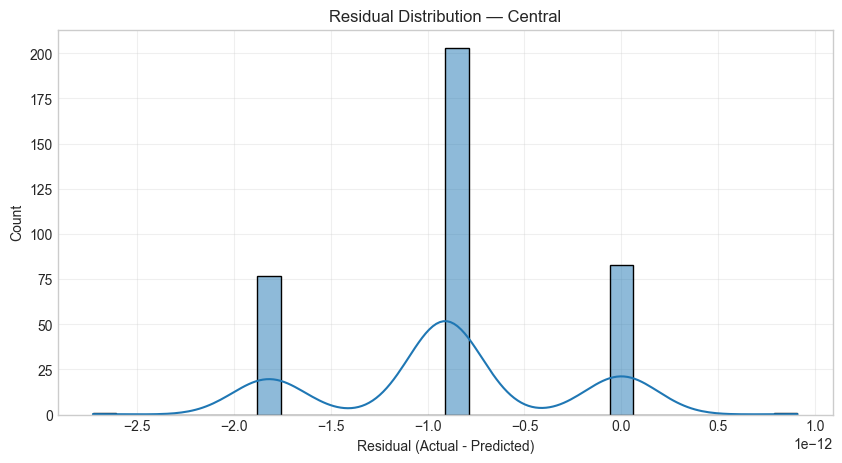

MAE=0.00, RMSE=0.00, R2=1.000


In [24]:
# %% [code]
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

region = "Central"
model_info = saved_models.get(region)
model_artifact = joblib.load(model_info['path'])
model = model_artifact['model']
scaler = model_artifact['scaler']
features = model_artifact['features']

# Prepare test set again
region_df = df[df.Region == region].sort_values("RecordDate").reset_index(drop=True)
X, y, feats = prepare_X_y(region_df)
X_train, X_test, y_train, y_test = time_split(X, y, test_days=365)

# Scale numeric features
num_cols = X_test.select_dtypes(include=[np.number]).columns.tolist()
X_test_scaled = X_test.copy()
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# Predict
y_pred = model.predict(X_test_scaled)

# --- Plots ---
plt.figure(figsize=(12,6))
plt.plot(region_df['RecordDate'].iloc[-365:], y_test, label='Actual')
plt.plot(region_df['RecordDate'].iloc[-365:], y_pred, label='Predicted')
plt.title(f"Actual vs Predicted Energy Demand — {region}")
plt.xlabel("Date")
plt.ylabel("Demand (MWh)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Residuals
residuals = y_test - y_pred
plt.figure(figsize=(10,5))
sns.histplot(residuals, bins=30, kde=True)
plt.title(f"Residual Distribution — {region}")
plt.xlabel("Residual (Actual - Predicted)")
plt.grid(alpha=0.3)
plt.show()

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")


#### **Next steps & extensions**
##### - Add hyperparameter tuning (GridSearchCV / RandomizedSearchCV) inside `TimeSeriesSplit` cross validation blocks (be careful with time leakage).  
##### - Add probabilistic forecasts via quantile regression / LightGBM quantile objective or conformal prediction.  
##### - Train generator-level models (solar/wind) using weather features and combine with demand forecasts for net-balance forecasting.  
##### - Implement battery dispatch optimization using forecasted prices and generation (next notebook: `03_Optimization_Scenarios.ipynb`).  
##### - Optionally convert daily models to hourly models (requires synthetic hourly data).